## MiniGrid-SimpleCrossingS11N5-v0: observaciones, acciones y forma de trabajo

Este material está pensado como una notebook guiada para introducir el entorno **MiniGrid-SimpleCrossingS11N5-v0** y preparar la implementación de agentes.
La idea es comprender qué información devuelve el entorno, cómo leerla y cómo usarla de forma razonable al diseñar agentes.

## 1. Importación de bibliotecas

In [ ]:
import gymnasium as gym
import minigrid
import numpy as np
import matplotlib.pyplot as plt
import time

from IPython.display import display, clear_output
from minigrid.core.grid import Grid
from minigrid.core.constants import OBJECT_TO_IDX, COLOR_TO_IDX, STATE_TO_IDX

Trabajaremos con `gymnasium`, que nos permite crear y ejecutar el entorno, y con `minigrid`, que registra los entornos disponibles.

La observación que devuelve MiniGrid viene codificada como una estructura numérica. Por eso conviene importar también `Grid.decode`, además de los diccionarios de constantes `OBJECT_TO_IDX`, `COLOR_TO_IDX` y `STATE_TO_IDX`, que permiten interpretar el significado de esos valores.

## 2. Creación del entorno

In [ ]:
ENV_NAME = "MiniGrid-SimpleCrossingS11N5-v0"
AGENT_VIEW_SIZE = 3
env = gym.make(ENV_NAME, render_mode="rgb_array", agent_view_size=AGENT_VIEW_SIZE)

En esta guía usaremos el entorno `MiniGrid-SimpleCrossingS11N5-v0`.

El parámetro `render_mode="rgb_array"` hace que el método `render()` devuelva una imagen como matriz de píxeles, lo cual resulta muy cómodo para mostrar el estado del entorno dentro de una notebook.

El parámetro `agent_view_size` fija el tamaño de la observación del agente. Trabajaremos con un tamaño de 3x3

## 3. Reinicio del entorno y primera observación

In [ ]:
obs, info = env.reset(seed=29)

print("Observation keys:", obs.keys())
print("Direction:", obs["direction"])
print("Mission:", obs["mission"])
print("Image shape:", obs["image"].shape)
print("Info:", info)

Observation keys: dict_keys(['image', 'direction', 'mission'])
Direction: 0
Mission: find the opening and get to the green goal square
Image shape: (3, 3, 3)
Info: {}


Cada episodio comienza con `reset()`. Esta función devuelve dos cosas:

- `obs`: la observación inicial del agente.
- `info`: un diccionario con información adicional.

La observación no es un número aislado ni una etiqueta simple. En MiniGrid suele venir como un diccionario con tres componentes principales:

- `image`: representación local de lo que el agente ve.
- `direction`: orientación del agente.
- `mission`: descripción textual de la tarea.

En este tipo de entornos, el componente más importante para diseñar agentes es `obs["image"]`, porque allí está la percepción local del mundo.

## 4. Vista global del entorno

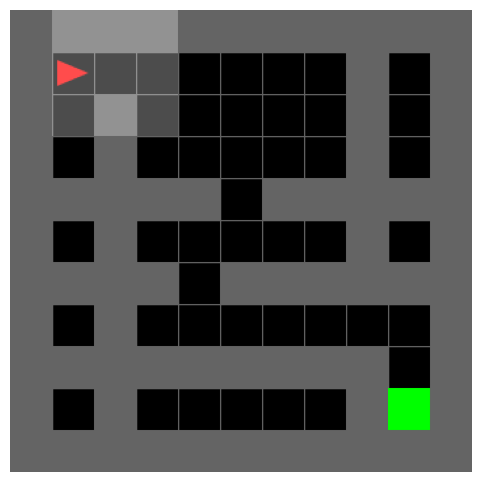

In [ ]:
frame = env.render()

plt.figure(figsize=(6, 6))
plt.imshow(frame)
plt.axis("off")
plt.show()

La imagen que devuelve `render()` muestra una **vista global** del entorno. Esta vista es útil para nosotros como observadores externos, pero no es la información que recibe directamente el agente.

Esto es importante: el agente no conoce el mapa completo. Solo recibe una vista local egocéntrica.

## 5. Estructura general de la observación

In [ ]:
print(type(obs))
print(obs.keys())
print(obs["image"].dtype)
print(obs["image"].shape)

<class 'dict'>
dict_keys(['image', 'direction', 'mission'])
uint8
(3, 3, 3)


La observación local `obs["image"]` suele ser un tensor de tres dimensiones:

```python
(height, width, channels)
```

Cada celda observada se codifica con tres números:

```python
(OBJECT_IDX, COLOR_IDX, STATE)
```

Esto significa que una celda no almacena directamente texto como `"wall"` o `"goal"`, sino índices enteros que luego debemos decodificar.

In [ ]:
obs["image"][2,1]

array([2, 5, 0], dtype=uint8)

## 6. Cómo leer la observación local

In [ ]:
def get_view_shape(obs):
    height, width = obs["image"].shape[:2]
    return height, width

def get_agent_view_coordinates(obs):
    height, width = get_view_shape(obs)
    agent_x = height // 2
    agent_y = width - 1
    return agent_x, agent_y

def explain_agent_reference_frame(obs):
    h, w, c = obs["image"].shape

    print(f"Observation shape: {obs['image'].shape}")
    print()
    print("Cómo leer esta observación:")
    print(f"- Las filas van de 0 a {h - 1}")
    print(f"- Las columnas van de 0 a {w - 1}")
    print("- La observación es egocéntrica: está organizada desde el punto de vista del agente.")
    print("- Las filas superiores corresponden a celdas más lejanas en la vista del agente.")
    print("- Las filas inferiores corresponden a celdas más cercanas al agente.")
    print("- Las columnas de la izquierda están a la izquierda del agente.")
    print("- Las columnas de la derecha están a la derecha del agente.")
    print()
    print("Importante:")
    print("- Esta observación NO está indexada según el mapa global.")
    print("- Si el agente gira, la observación cambia de orientación también.")

explain_agent_reference_frame(obs)
print("Posición del agente en la vista:", get_agent_view_coordinates(obs))

Observation shape: (3, 3, 3)

Cómo leer esta observación:
- Las filas van de 0 a 2
- Las columnas van de 0 a 2
- La observación es egocéntrica: está organizada desde el punto de vista del agente.
- Las filas superiores corresponden a celdas más lejanas en la vista del agente.
- Las filas inferiores corresponden a celdas más cercanas al agente.
- Las columnas de la izquierda están a la izquierda del agente.
- Las columnas de la derecha están a la derecha del agente.

Importante:
- Esta observación NO está indexada según el mapa global.
- Si el agente gira, la observación cambia de orientación también.
Posición del agente en la vista: (1, 2)


La observación es **egocéntrica**. Esto quiere decir que no está expresada en coordenadas globales del mapa, sino en coordenadas relativas al agente.

Cuando el agente gira, la observación también cambia de orientación. Por eso es muy importante no confundir:

- la posición del agente en el mapa global,
- con la posición de referencia del agente dentro de su observación local.

## 7. Visualización de índices y valores de la observación

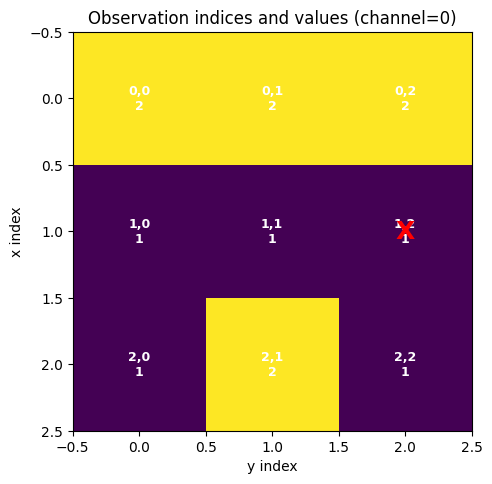

In [ ]:
def show_observation_indices(obs, channel=0, figsize=(5, 5)):
    data = obs["image"][:, :, channel]
    h, w = data.shape

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(data, cmap="viridis")

    for x in range(h):
        for y in range(w):
            ax.text(
                y,
                x,
                f"{x},{y}\n{data[x, y]}",
                ha="center",
                va="center",
                color="white",
                fontsize=9,
                fontweight="bold"
            )

    agent_x, agent_y = get_agent_view_coordinates(obs)

    ax.text(
        agent_y,
        agent_x,
        "X",
        color="red",
        fontsize=18,
        fontweight="bold",
        ha="center",
        va="center"
    )

    ax.set_title(f"Observation indices and values (channel={channel})")
    ax.set_xlabel("y index")
    ax.set_ylabel("x index")
    plt.tight_layout()
    plt.show()

show_observation_indices(obs, channel=0)

Esta visualización ayuda a entender dos cosas.

Primero, que cada celda observada tiene una ubicación local dentro de la ventana perceptual.

Segundo, que el canal 0 representa el tipo de objeto. Más adelante decodificaremos esos valores para pasar de índices numéricos a significados como pared, meta, piso o lava.

## 8. Diccionarios de decodificación

In [ ]:
IDX_TO_OBJECT = {v: k for k, v in OBJECT_TO_IDX.items()}
IDX_TO_COLOR = {v: k for k, v in COLOR_TO_IDX.items()}
IDX_TO_STATE = {v: k for k, v in STATE_TO_IDX.items()}

print("OBJECT_TO_IDX =", OBJECT_TO_IDX)
print("COLOR_TO_IDX =", COLOR_TO_IDX)
print("STATE_TO_IDX =", STATE_TO_IDX)

OBJECT_TO_IDX = {'unseen': 0, 'empty': 1, 'wall': 2, 'floor': 3, 'door': 4, 'key': 5, 'ball': 6, 'box': 7, 'goal': 8, 'lava': 9, 'agent': 10}
COLOR_TO_IDX = {'red': 0, 'green': 1, 'blue': 2, 'purple': 3, 'yellow': 4, 'grey': 5}
STATE_TO_IDX = {'open': 0, 'closed': 1, 'locked': 2}


MiniGrid codifica simbólicamente el entorno usando índices enteros.

En `SimpleCrossing`, los objetos más relevantes para el trabajo con agentes suelen ser:

- `wall`: obstáculo que no puede atravesarse.
- `goal`: celda objetivo.
- `floor` o celdas transitables.

El modo más seguro de trabajar no es memorizar índices, sino usar siempre estos diccionarios o `Grid.decode()`.

## 9. Decodificación semántica de la observación

In [ ]:
def decode_percept_grid(obs):
    percept_grid, visibility_mask = Grid.decode(obs["image"])
    return percept_grid, visibility_mask

percept_grid, visibility_mask = decode_percept_grid(obs)

for x in range(obs["image"].shape[0]):
    for y in range(obs["image"].shape[1]):
        cell = percept_grid.get(x, y)
        if cell is None:
            print(f"cell at ({x}, {y}): None")
        else:
            print(f"cell at ({x}, {y}): type={cell.type}, color={cell.color}")

cell at (0, 0): type=wall, color=grey
cell at (0, 1): type=wall, color=grey
cell at (0, 2): type=wall, color=grey
cell at (1, 0): None
cell at (1, 1): None
cell at (1, 2): None
cell at (2, 0): None
cell at (2, 1): type=wall, color=grey
cell at (2, 2): None


`Grid.decode()` transforma la observación cruda en una grilla de objetos más fácil de consultar.

Esto resulta mucho más cómodo que trabajar directamente con números. En lugar de preguntar si el valor del canal 0 es un índice particular, podés hacer preguntas semánticas como:

- `cell.type == "wall"`
- `cell.type == "goal"`
- `cell.can_overlap()`

## 10. Máscara de visibilidad

In [ ]:
print("Visibility mask shape:", visibility_mask.shape)
print(visibility_mask.astype(int))

Visibility mask shape: (3, 3)
[[1 1 1]
 [1 1 1]
 [1 1 1]]


La máscara de visibilidad indica qué posiciones de la ventana perceptual son realmente visibles.

Cuando un agente razona sobre su observación, conviene distinguir entre:

- celdas visibles y transitables,
- celdas visibles pero bloqueadas,
- celdas no visibles.

Una celda no visible no debería tratarse como libre solo porque no tenemos información.

## 11. Identificación de celdas relevantes: frente, izquierda y derecha

In [ ]:
def get_front_coordinates(obs):
    agent_x, agent_y = get_agent_view_coordinates(obs)
    return agent_x, agent_y - 1


def get_left_coordinates(obs):
    agent_x, agent_y = get_agent_view_coordinates(obs)
    return agent_x - 1, agent_y


def get_right_coordinates(obs):
    agent_x, agent_y = get_agent_view_coordinates(obs)
    return agent_x + 1, agent_y


print("Front:", get_front_coordinates(obs))
print("Left:", get_left_coordinates(obs))
print("Right:", get_right_coordinates(obs))

Front: (1, 1)
Left: (0, 2)
Right: (2, 2)


Estas funciones permiten referirse rápidamente a las celdas vecinas más relevantes desde el punto de vista del agente.

## 12. Cómo verificar si una celda local está libre

In [ ]:
def cell_is_clear(percept_grid, visibility_mask, x, y):
    height, width = visibility_mask.shape

    if x < 0 or x >= height or y < 0 or y >= width:
        return False

    if not visibility_mask[x, y]:
        return False

    cell = percept_grid.get(x, y)

    if cell is None:
        return True

    return cell.can_overlap()

front_x, front_y = get_front_coordinates(obs)
left_x, left_y = get_left_coordinates(obs)
right_x, right_y = get_right_coordinates(obs)

print("Front clear:", cell_is_clear(percept_grid, visibility_mask, front_x, front_y))
print("Left clear:", cell_is_clear(percept_grid, visibility_mask, left_x, left_y))
print("Right clear:", cell_is_clear(percept_grid, visibility_mask, right_x, right_y))

Front clear: True
Left clear: False
Right clear: True


Conviene seguir este criterio:

- Si la coordenada cae fuera del percepto, no se considera libre.
- Si la celda no es visible, no se considera libre.
- Si no hay objeto explícito (`None`), se la considera transitable.
- Si hay un objeto, se consulta `cell.can_overlap()`.

Esto encapsula de forma limpia la pregunta: **¿puedo ocupar esa celda o no?**

`cell.can_overlap()` devuelve si el agente puede pasar por esa celda. Por ejemplo, una pared típicamente no permite superposición, mientras que una meta o una celda de suelo sí.

## 13. Resumen local de celdas transitables

In [ ]:
def local_clearances(obs):
    percept_grid, visibility_mask = decode_percept_grid(obs)

    front_x, front_y = get_front_coordinates(obs)
    left_x, left_y = get_left_coordinates(obs)
    right_x, right_y = get_right_coordinates(obs)

    return {
        "front": cell_is_clear(percept_grid, visibility_mask, front_x, front_y),
        "left": cell_is_clear(percept_grid, visibility_mask, left_x, left_y),
        "right": cell_is_clear(percept_grid, visibility_mask, right_x, right_y),
    }

print(local_clearances(obs))

{'front': True, 'left': False, 'right': True}


Este tipo de función es muy útil porque resume la información local más inmediata en una estructura simple.

## 14. Detección de la meta en la observación actual

In [ ]:
def goal_relative_position(obs):
    percept_grid, visibility_mask = decode_percept_grid(obs)
    height, width = obs["image"].shape[:2]

    for y in range(width):
        for x in range(height):
            if not visibility_mask[x, y]:
                continue

            cell = percept_grid.get(x, y)
            if cell is not None and cell.type == "goal":
                return x, y

    return None

print("Goal relative position:", goal_relative_position(obs))

Goal relative position: None


La meta puede no estar visible durante buena parte del episodio. Por eso conviene diseñar los agentes pensando en dos modos de comportamiento:

- exploración, cuando la meta no se ve;
- aproximación dirigida, cuando la meta aparece en el percepto.

## 15. Orientación del agente

In [ ]:
print("Agent global direction:", obs["direction"])

Agent global direction: 0


MiniGrid representa la orientación del agente con un entero. En muchos ejemplos prácticos se usa esta convención:

- `0`: right
- `1`: down
- `2`: left
- `3`: up

Entender la orientación global resulta útil cuando queremos conectar percepción local con memoria interna.

## 16. Espacio de acciones

In [ ]:
print("Action space:", env.action_space)
print("Sample action:", env.action_space.sample())

Action space: Discrete(7)
Sample action: 5


En MiniGrid, el espacio de acciones es discreto. Eso significa que cada acción está representada por un número entero.

Conviene trabajar con nombres simbólicos para no tener que recordar índices de memoria.

## 18. Mapeo entre nombres de acciones e índices

In [ ]:
ACTION_TO_INDEX = {
    "left": 0,
    "right": 1,
    "forward": 2,
    "pickup": 3,
    "drop": 4,
    "toggle": 5,
    "done": 6,
}

INDEX_TO_ACTION = {value: key for key, value in ACTION_TO_INDEX.items()}

print(ACTION_TO_INDEX)

{'left': 0, 'right': 1, 'forward': 2, 'pickup': 3, 'drop': 4, 'toggle': 5, 'done': 6}


En `SimpleCrossing`, las acciones más importantes para nuestros agentes serán principalmente:

- `left`: girar a la izquierda.
- `right`: girar a la derecha.
- `forward`: avanzar.

## 19. Ejecución manual de una acción

Reward: 0
Terminated: False
Truncated: False
Info: {}


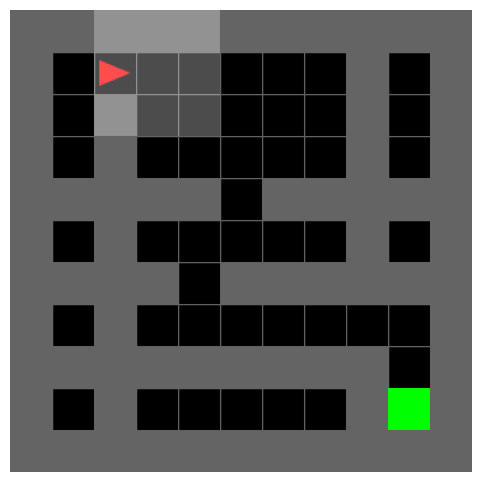

In [ ]:
action = ACTION_TO_INDEX["forward"]

next_obs, reward, terminated, truncated, info = env.step(action)

print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)
print("Info:", info)

plt.figure(figsize=(6, 6))
plt.imshow(env.render())
plt.axis("off")
plt.show()

El método `step(action)` es el núcleo de la interacción con el entorno.

Devuelve cinco elementos:

- `next_obs`: la nueva observación.
- `reward`: la recompensa recibida.
- `terminated`: si el episodio terminó por cumplir la condición de finalización.
- `truncated`: si el episodio fue cortado por límite de pasos u otra restricción externa.
- `info`: información adicional.

## 20. Funciones para visualización y animación

In [ ]:
def show_frame(frame, figsize=(5, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(frame)
    plt.axis("off")
    plt.show()


def animate_frames(frames, delay=0.2, figsize=(5, 5)):
    for frame in frames:
        clear_output(wait=True)
        plt.figure(figsize=figsize)
        plt.imshow(frame)
        plt.axis("off")
        display(plt.gcf())
        plt.close()
        time.sleep(delay)

Estas funciones no son parte de la lógica del agente, pero ayudan mucho a inspeccionar su comportamiento.

Cuando un agente falla, la animación permite detectar problemas clásicos como oscilaciones, giros repetidos o exploración poco eficiente.

## 21. Una función general para correr un episodio

In [ ]:
class BaseAgent:
    def reset(self):
        pass

    def act(self, observation, env):
        raise NotImplementedError("Subclasses must implement the act method.")


class RandomAgent(BaseAgent):
    def reset(self):
        pass

    def act(self, observation, env):
        return env.action_space.sample()

class SimpleReflexAgent(BaseAgent):
    """Agente Reflejo Simple"""

class ModelBasedReflexAgent(BaseAgent):
    """Agente Reflejo Basado en Modelo"""

# Opcional
class ImprovedModelAgent(BaseAgent):
    """Agente Basado en Modelo Mejorado"""

def run_episode(env, agent, max_steps=100, seed=None, collect_frames=True):
    observation, info = env.reset(seed=seed)
    agent.reset()

    frames = []
    total_reward = 0.0
    steps = 0
    terminated = False
    truncated = False

    if collect_frames:
        frames.append(env.render())

    for _ in range(max_steps):
        action = agent.act(observation, env)
        observation, reward, terminated, truncated, info = env.step(action)

        total_reward += reward
        steps += 1

        if collect_frames:
            frames.append(env.render())

        if terminated or truncated:
            break

    result = {
        "frames": frames,
        "total_reward": total_reward,
        "steps": steps,
        "terminated": terminated,
        "truncated": truncated,
        "success": bool(terminated),
    }

    return result

Esta función permite separar claramente tres cosas:

- la lógica del entorno,
- la lógica del agente,
- la recolección de métricas y visualizaciones.

## 22. Prueba rápida con un agente aleatorio

In [ ]:
agent = RandomAgent()
result = run_episode(env, agent, max_steps=50, seed=4, collect_frames=True)

print("Total reward:", result["total_reward"])
print("Steps:", result["steps"])
print("Success:", result["success"])
print("Terminated:", result["terminated"])
print("Truncated:", result["truncated"])
print("Number of frames:", len(result["frames"]))

Total reward: 0.0
Steps: 50
Success: False
Terminated: False
Truncated: False
Number of frames: 51


El agente aleatorio no es útil para resolver el problema de manera eficiente, pero sí sirve para comprobar que la infraestructura básica funciona.

## 23. Animación del episodio

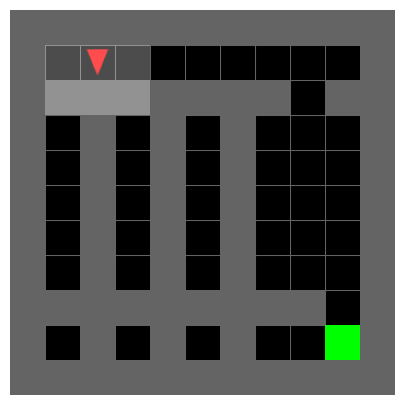

In [ ]:
animate_frames(result["frames"], delay=0.2)

Observar episodios completos es muy valioso antes de diseñar reglas más sofisticadas. Muchas veces los errores de diseño no se entienden leyendo el código, sino mirando el comportamiento efectivo del agente en el entorno.

## 24. Recomendaciones prácticas para trabajar con MiniGrid-SimpleCrossingS11N5-v0

### 24.1 No usar la vista global para decidir

La imagen devuelta por `render()` es útil para visualización humana, pero no debería formar parte de la lógica del agente.

### 24.2 No hardcodear índices numéricos sin necesidad

En lugar de asumir índices fijos, conviene trabajar con:

- `Grid.decode()`
- `cell.type`
- `cell.can_overlap()`
- los diccionarios de constantes

### 24.3 Separar percepción local y estado interno

Una cosa es lo que el agente ve ahora. Otra es lo que recuerda de pasos anteriores.

### 24.4 Empezar con reglas locales simples

Antes de intentar comportamientos más complejos, conviene responder preguntas como:

- ¿adelante está libre?
- ¿la meta se ve?
- ¿hay que girar a izquierda o derecha?

### 24.5 Usar seeds controladas al comparar agentes

Si queremos comparar agentes, es recomendable ejecutar ambos bajo las mismas condiciones iniciales.

### 24.6 Mirar episodios individuales, no solo métricas agregadas

Dos agentes pueden tener tasas de éxito parecidas pero comportamientos muy distintos.

## 25. Cierre del entorno

In [ ]:
env.close()